# BARRA-RE2 wind drought identification from fixed P20 threshold

This notebook applies the saved climatological `wind100_p20` threshold to the monthly BARRA-RE2 `wind100_YYYY-MM.nc` files.

Output:
- One yearly NetCDF per year.
- Variable: `wind_drought`
- Dimensions: `time, realization, lon, lat`
- Values: `1 = drought event day`, `0 = non-drought`
- Definition: `wind100 < P20` for at least 3 consecutive days.

In [1]:
from pathlib import Path
import os
import gc
import queue
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import xarray as xr
from netCDF4 import Dataset, date2num
from tqdm.auto import tqdm

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# Close old Dask cluster if it exists
try:
    client.close()
    cluster.close()
except Exception:
    pass

In [2]:
# =========================
# Settings
# =========================

VAR_NAME = "wind100"
THRESHOLD_VAR = "wind100_p20"

PATH = Path("/scratch/ng72/ha2606/barra_re2_wind100_monthly_nc/")

THRESHOLD_FILE = Path(
    "/scratch/ng72/ha2606/barra_re2_wind100_thresholds/"
    "wind100_P20_threshold_1991_2020_by_realization_exact.nc"
)

OUT_DIR = Path("/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Australia bounds
lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

THRESHOLD_PERCENTILE = 20
PERSISTENCE_DAYS = 3

# Set to None to use all years found in PATH
YEAR_START = None
YEAR_END = None

# Safer default for NetCDF I/O.
# Increase to 6 or 8 if the file system is behaving well.
N_WORKERS_YEARS = 4

FORCE_REFRESH = False

print("Input monthly directory:", PATH)
print("Threshold file:", THRESHOLD_FILE)
print("Output directory:", OUT_DIR)

Input monthly directory: /scratch/ng72/ha2606/barra_re2_wind100_monthly_nc
Threshold file: /scratch/ng72/ha2606/barra_re2_wind100_thresholds/wind100_P20_threshold_1991_2020_by_realization_exact.nc
Output directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly


In [3]:
# =========================
# Build sorted monthly file table
# =========================

monthly_files = sorted(PATH.glob("wind100_*.nc"))

if len(monthly_files) == 0:
    raise FileNotFoundError(f"No NetCDF files found in: {PATH}")

paths = pd.DataFrame(monthly_files, columns=["path"])

paths["year"] = (
    paths["path"].astype(str)
    .str.split("_").str[-1]
    .str.split("-").str[0]
    .astype(int)
)

paths["month"] = (
    paths["path"].astype(str)
    .str.split("_").str[-1]
    .str.split("-").str[-1]
    .str.split(".").str[0]
    .astype(int)
)

paths = (
    paths.sort_values(["year", "month"])
    .drop_duplicates(["year", "month"], keep="first")
    .reset_index(drop=True)
)

available_years = sorted(paths["year"].unique())

if YEAR_START is None:
    YEAR_START = int(min(available_years))

if YEAR_END is None:
    YEAR_END = int(max(available_years))

years_to_process = [y for y in available_years if YEAR_START <= y <= YEAR_END]

print(f"Monthly files found: {len(paths)}")
print(f"Available years: {min(available_years)} to {max(available_years)}")
print(f"Years to process: {min(years_to_process)} to {max(years_to_process)}")
print("First file:", paths.iloc[0]["path"])
print("Last file :", paths.iloc[-1]["path"])

display(paths.head())
display(paths.tail())
display(paths.groupby("year")["month"].count().to_frame("n_months"))

Monthly files found: 424
Available years: 1990 to 2025
Years to process: 1990 to 2025
First file: /scratch/ng72/ha2606/barra_re2_wind100_monthly_nc/wind100_1990-01.nc
Last file : /scratch/ng72/ha2606/barra_re2_wind100_monthly_nc/wind100_2025-04.nc


,path,year,month
0,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,1990,1
1,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,1990,2
2,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,1990,3
3,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,1990,4
4,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,1990,5


,path,year,month
419,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,2024,12
420,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,2025,1
421,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,2025,2
422,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,2025,3
423,/scratch/ng72/ha2606/barra_re2_wind100_monthly...,2025,4


,n_months
year,
1990,12
1991,12
1992,12
1993,12
1994,12
1995,12
1996,12
1997,12
1998,12


In [4]:
# =========================
# Load and subset fixed P20 threshold
# =========================

if not THRESHOLD_FILE.exists():
    raise FileNotFoundError(f"Threshold file not found: {THRESHOLD_FILE}")

threshold_ds = xr.open_dataset(THRESHOLD_FILE)
p20 = threshold_ds[THRESHOLD_VAR]

# Robust Australia subset, regardless of coordinate ordering
p20_aus = p20.where(
    (p20["lon"] >= lon_min) & (p20["lon"] <= lon_max) &
    (p20["lat"] >= lat_min) & (p20["lat"] <= lat_max),
    drop=True
).load()

# Stable dimension order
p20_aus = p20_aus.transpose("realization", "lon", "lat").astype("float32")

p20_vals = p20_aus.values.astype("float32", copy=False)
realization_vals = p20_aus["realization"].values
lon_vals = p20_aus["lon"].values
lat_vals = p20_aus["lat"].values

n_real = p20_aus.sizes["realization"]
n_lon = p20_aus.sizes["lon"]
n_lat = p20_aus.sizes["lat"]

print(p20_aus)
print("Threshold shape:", p20_vals.shape)
print("n_realization:", n_real)
print("n_lon:", n_lon)
print("n_lat:", n_lat)
print("P20 min/max:", float(np.nanmin(p20_vals)), float(np.nanmax(p20_vals)))

threshold_ds.close()

<xarray.DataArray 'wind100_p20' (realization: 22, lon: 227, lat: 159)> Size: 3MB
array([[[8.750836 , 8.669046 , 8.606773 , ..., 4.1320286, 4.0809197,
         4.049328 ],
        [8.728962 , 8.657872 , 8.596522 , ..., 4.1230907, 4.086361 ,
         4.051309 ],
        [8.710478 , 8.644672 , 8.588184 , ..., 4.105535 , 4.0661073,
         4.036305 ],
        ...,
        [6.230355 , 6.1461334, 6.073928 , ..., 3.108443 , 2.9468758,
         2.7117682],
        [6.2088194, 6.1577287, 6.1011815, ..., 3.0492039, 2.7918522,
         2.3247592],
        [6.252513 , 6.183467 , 6.1100583, ..., 2.9930406, 2.6453118,
         2.0665717]],

       [[8.73873  , 8.681048 , 8.612409 , ..., 4.288274 , 4.212774 ,
         4.149533 ],
        [8.749119 , 8.673881 , 8.58791  , ..., 4.255964 , 4.171704 ,
         4.1348867],
        [8.747897 , 8.637852 , 8.574964 , ..., 4.224808 , 4.163389 ,
         4.1128497],
...
        [6.2478285, 6.1961684, 6.148368 , ..., 3.1126366, 2.9351826,
         2.6559677],


In [5]:
# =========================
# Helpers
# =========================

def files_for_year_with_halo(year, paths_df):
    '''
    For 3-day persistence, include:
    - previous December
    - all months in target year
    - next January

    The output is later cropped back to the target year.
    '''
    use = (
        ((paths_df["year"] == year - 1) & (paths_df["month"] == 12)) |
        (paths_df["year"] == year) |
        ((paths_df["year"] == year + 1) & (paths_df["month"] == 1))
    )

    files_df = paths_df.loc[use].sort_values(["year", "month"]).reset_index(drop=True)
    return files_df["path"].tolist()


def load_wind100_year_with_halo(year_files, p20_lon, p20_lat):
    '''
    Load selected monthly files into memory as:
        data shape = time, realization, lon, lat

    This uses the threshold coordinates to subset Australia and ensure grid alignment.
    '''
    arrays = []
    times = []

    for fp in year_files:
        with xr.open_dataset(fp, engine="netcdf4", decode_times=True) as ds:
            if VAR_NAME not in ds.data_vars:
                raise KeyError(f"{VAR_NAME} not found in {fp}. Found: {list(ds.data_vars)}")

            da = ds[VAR_NAME]

            # Select same Australia grid as threshold
            try:
                da = da.sel(lon=p20_lon, lat=p20_lat)
            except Exception:
                # fallback for very tiny coordinate rounding differences
                da = da.sel(lon=p20_lon, lat=p20_lat, method="nearest")

                max_lon_err = float(np.max(np.abs(da["lon"].values - p20_lon)))
                max_lat_err = float(np.max(np.abs(da["lat"].values - p20_lat)))

                if max_lon_err > 1e-6 or max_lat_err > 1e-6:
                    raise ValueError(
                        f"Threshold grid and data grid do not match closely enough. "
                        f"max_lon_err={max_lon_err}, max_lat_err={max_lat_err}"
                    )

            da = da.transpose("time", "realization", "lon", "lat")

            arr = da.values.astype("float32", copy=False)
            arrays.append(arr)

            times.append(da["time"].values)

    data = np.concatenate(arrays, axis=0)
    time_vals = np.concatenate(times, axis=0)

    # Sort time and remove duplicates if any
    order = np.argsort(time_vals)
    time_vals = time_vals[order]
    data = data[order]

    _, unique_idx = np.unique(time_vals, return_index=True)
    unique_idx = np.sort(unique_idx)

    time_vals = time_vals[unique_idx]
    data = data[unique_idx]

    return data, time_vals


def persistent_mask_fast(candidate, min_len=3):
    '''
    Vectorized persistence filter.

    Input:
        candidate shape = time, realization, lon, lat
        True where wind100 < P20

    Output:
        int8 mask with same shape
        1 where candidate belongs to a run of at least min_len consecutive True days.
    '''
    candidate = np.asarray(candidate, dtype=bool)
    out = np.zeros(candidate.shape, dtype=np.int8)

    n_time = candidate.shape[0]

    if n_time < min_len:
        return out

    # starts[t] is True where a run of length min_len starts at day t
    starts = candidate[: n_time - min_len + 1].copy()

    for k in range(1, min_len):
        starts &= candidate[k : k + n_time - min_len + 1]

    # Mark all days that are part of any valid run
    for k in range(min_len):
        out[k : k + starts.shape[0]] |= starts

    return out


def write_year_netcdf(outfile, wind_drought, time_vals, realization_vals, lon_vals, lat_vals, year):
    '''
    Write yearly drought mask directly with netCDF4.
    '''
    if outfile.exists():
        outfile.unlink()

    time_pd = pd.to_datetime(time_vals)
    time_units = "days since 1950-01-01 00:00:00"
    calendar = "proleptic_gregorian"

    with Dataset(outfile, "w", format="NETCDF4") as nc:
        nc.createDimension("time", len(time_pd))
        nc.createDimension("realization", len(realization_vals))
        nc.createDimension("lon", len(lon_vals))
        nc.createDimension("lat", len(lat_vals))

        tvar = nc.createVariable("time", "f8", ("time",))
        rvar = nc.createVariable("realization", realization_vals.dtype, ("realization",))
        lonvar = nc.createVariable("lon", lon_vals.dtype, ("lon",))
        latvar = nc.createVariable("lat", lat_vals.dtype, ("lat",))

        tvar[:] = date2num(time_pd.to_pydatetime(), units=time_units, calendar=calendar)
        tvar.units = time_units
        tvar.calendar = calendar
        tvar.long_name = "time"

        rvar[:] = realization_vals
        lonvar[:] = lon_vals
        latvar[:] = lat_vals

        lonvar.units = "degrees_east"
        latvar.units = "degrees_north"

        outvar = nc.createVariable(
            "wind_drought",
            "i1",
            ("time", "realization", "lon", "lat"),
            zlib=True,
            complevel=1,
            shuffle=True,
            fill_value=np.int8(-127),
        )

        outvar[:, :, :, :] = wind_drought.astype(np.int8, copy=False)

        outvar.long_name = (
            f"Wind drought mask: 1 = {VAR_NAME} < P{THRESHOLD_PERCENTILE} "
            f"for at least {PERSISTENCE_DAYS} consecutive days"
        )
        outvar.definition = "1 = wind drought event day, 0 = non-drought"
        outvar.threshold_percentile = THRESHOLD_PERCENTILE
        outvar.persistence_threshold_days = PERSISTENCE_DAYS
        outvar.threshold_file = str(THRESHOLD_FILE)
        outvar.source_variable = VAR_NAME
        outvar.units = "1"

        nc.title = f"BARRA-RE2 wind drought mask for {year}"
        nc.history = "Created from monthly wind100 files using fixed 1991-2020 P20 threshold"
        nc.region = "Australia"
        nc.lon_min = lon_min
        nc.lon_max = lon_max
        nc.lat_min = lat_min
        nc.lat_max = lat_max

In [6]:
# =========================
# Main worker: process one year
# =========================

def process_one_year(task):
    '''
    Process one year:
    1. load target year plus boundary halo months,
    2. compare wind100 against fixed P20 threshold,
    3. apply 3-day persistence filter,
    4. crop back to target year,
    5. write yearly NetCDF.
    '''
    (
        year,
        paths_records,
        p20_vals,
        realization_vals,
        lon_vals,
        lat_vals,
        out_dir,
        force_refresh,
    ) = task

    paths_df = pd.DataFrame.from_records(paths_records)
    out_dir = Path(out_dir)

    outfile = out_dir / f"wind_drought_P{THRESHOLD_PERCENTILE}_{PERSISTENCE_DAYS}day_{year}.nc"

    if outfile.exists() and not force_refresh:
        return {
            "year": year,
            "status": "exists",
            "outfile": str(outfile),
            "n_days": None,
            "drought_fraction": None,
            "error": None,
        }

    try:
        year_files = files_for_year_with_halo(year, paths_df)

        if len(year_files) == 0:
            raise FileNotFoundError(f"No files found for {year}")

        data, time_vals = load_wind100_year_with_halo(
            year_files=year_files,
            p20_lon=lon_vals,
            p20_lat=lat_vals,
        )

        # Basic shape check
        expected_shape_tail = p20_vals.shape
        if data.shape[1:] != expected_shape_tail:
            raise ValueError(
                f"Data shape and threshold shape do not match. "
                f"data tail={data.shape[1:]}, p20={expected_shape_tail}"
            )

        # Candidate drought days: wind100 < fixed P20
        candidate = data < p20_vals[None, :, :, :]

        # 3-day persistence filter
        drought_full = persistent_mask_fast(candidate, min_len=PERSISTENCE_DAYS)

        # Crop back to target calendar year
        time_index = pd.to_datetime(time_vals)
        target_start = pd.Timestamp(f"{year}-01-01")
        target_end = pd.Timestamp(f"{year + 1}-01-01")

        keep = (time_index >= target_start) & (time_index < target_end)

        if not np.any(keep):
            raise ValueError(f"No target-year days found after halo loading for {year}")

        drought_year = drought_full[keep, :, :, :]
        time_year = time_vals[keep]

        drought_fraction = float(drought_year.mean())

        write_year_netcdf(
            outfile=outfile,
            wind_drought=drought_year,
            time_vals=time_year,
            realization_vals=realization_vals,
            lon_vals=lon_vals,
            lat_vals=lat_vals,
            year=year,
        )

        n_days = int(drought_year.shape[0])

        del data, candidate, drought_full, drought_year
        gc.collect()

        return {
            "year": year,
            "status": "saved",
            "outfile": str(outfile),
            "n_days": n_days,
            "drought_fraction": drought_fraction,
            "error": None,
        }

    except Exception as e:
        return {
            "year": year,
            "status": "failed",
            "outfile": str(outfile),
            "n_days": None,
            "drought_fraction": None,
            "error": repr(e),
        }

In [7]:
# =========================
# Test on one year first
# =========================

TEST_YEAR = years_to_process[0]

paths_records = paths.to_dict("records")

test_task = (
    TEST_YEAR,
    paths_records,
    p20_vals,
    realization_vals,
    lon_vals,
    lat_vals,
    str(OUT_DIR),
    True,   # force refresh for test year
)

test_result = process_one_year(test_task)
test_result

{'year': np.int64(1990),
 'status': 'saved',
 'outfile': '/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc',
 'n_days': 365,
 'drought_fraction': 0.07068005342087251,
 'error': None}

In [8]:
# =========================
# Run all years
# =========================

tasks = [
    (
        year,
        paths_records,
        p20_vals,
        realization_vals,
        lon_vals,
        lat_vals,
        str(OUT_DIR),
        FORCE_REFRESH,
    )
    for year in years_to_process
]

results = []

ctx = mp.get_context("fork")

with ProcessPoolExecutor(max_workers=N_WORKERS_YEARS, mp_context=ctx) as executor:
    futures = {
        executor.submit(process_one_year, task): task[0]
        for task in tasks
    }

    for future in tqdm(
        as_completed(futures),
        total=len(futures),
        desc="Processing yearly wind drought masks",
        unit="year",
    ):
        result = future.result()
        results.append(result)

        if result["status"] == "failed":
            print(f"FAILED {result['year']}: {result['error']}", flush=True)
        else:
            print(
                f"{result['year']} | {result['status']} | "
                f"days={result['n_days']} | "
                f"drought_fraction={result['drought_fraction']} | "
                f"{result['outfile']}",
                flush=True,
            )

results_df = pd.DataFrame(results).sort_values("year").reset_index(drop=True)
display(results_df)

summary_file = OUT_DIR / "wind_drought_yearly_processing_summary.csv"
results_df.to_csv(summary_file, index=False)

print(f"Saved summary: {summary_file}")

Processing yearly wind drought masks:   0%|          | 0/36 [00:00<?, ?year/s]

1990 | exists | days=None | drought_fraction=None | /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
1991 | exists | days=None | drought_fraction=None | /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1991.nc
1992 | exists | days=None | drought_fraction=None | /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1992.nc
1994 | exists | days=None | drought_fraction=None | /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1994.nc
1993 | exists | days=None | drought_fraction=None | /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1993.nc
1995 | exists | days=None | drought_fraction=None | /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1995.nc
1996 | exists | days=None | drought_fraction=None | /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1996.nc
1997 | exists

,year,status,outfile,n_days,drought_fraction,error
0,1990,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None
1,1991,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None
2,1992,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None
3,1993,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None
4,1994,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None
5,1995,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None
6,1996,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None
7,1997,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None
8,1998,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None
9,1999,exists,/scratch/ng72/ha2606/barra_re2_wind100_drought...,None,None,None


Saved summary: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_yearly_processing_summary.csv


In [9]:
# =========================
# Quick check one output file
# =========================

saved_files = sorted(OUT_DIR.glob(f"wind_drought_P{THRESHOLD_PERCENTILE}_{PERSISTENCE_DAYS}day_*.nc"))

print(f"Saved output files: {len(saved_files)}")

if saved_files:
    check_file = saved_files[0]
    print("Checking:", check_file)

    check = xr.open_dataset(check_file)
    print(check)
    print("Unique values:", np.unique(check["wind_drought"].values))
    print("Mean drought fraction:", float(check["wind_drought"].mean().values))
    check.close()

Saved output files: 36
Checking: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
<xarray.Dataset> Size: 1GB
Dimensions:       (time: 365, realization: 22, lon: 227, lat: 159)
Coordinates:
  * time          (time) datetime64[ns] 3kB 1990-01-01T12:00:00 ... 1990-12-3...
  * realization   (realization) <U5 440B '000_0' '000_1' ... 'ctl_0' 'ctl_1'
  * lon           (lon) float64 2kB 110.2 110.4 110.7 ... 159.5 159.7 159.9
  * lat           (lat) float64 1kB -44.83 -44.61 -44.39 ... -10.29 -10.07
Data variables:
    wind_drought  (time, realization, lon, lat) float32 1GB ...
Attributes:
    title:    BARRA-RE2 wind drought mask for 1990
    history:  Created from monthly wind100 files using fixed 1991-2020 P20 th...
    region:   Australia
    lon_min:  110
    lon_max:  160
    lat_min:  -45
    lat_max:  -10
Unique values: [0. 1.]
Mean drought fraction: 0.07068005204200745


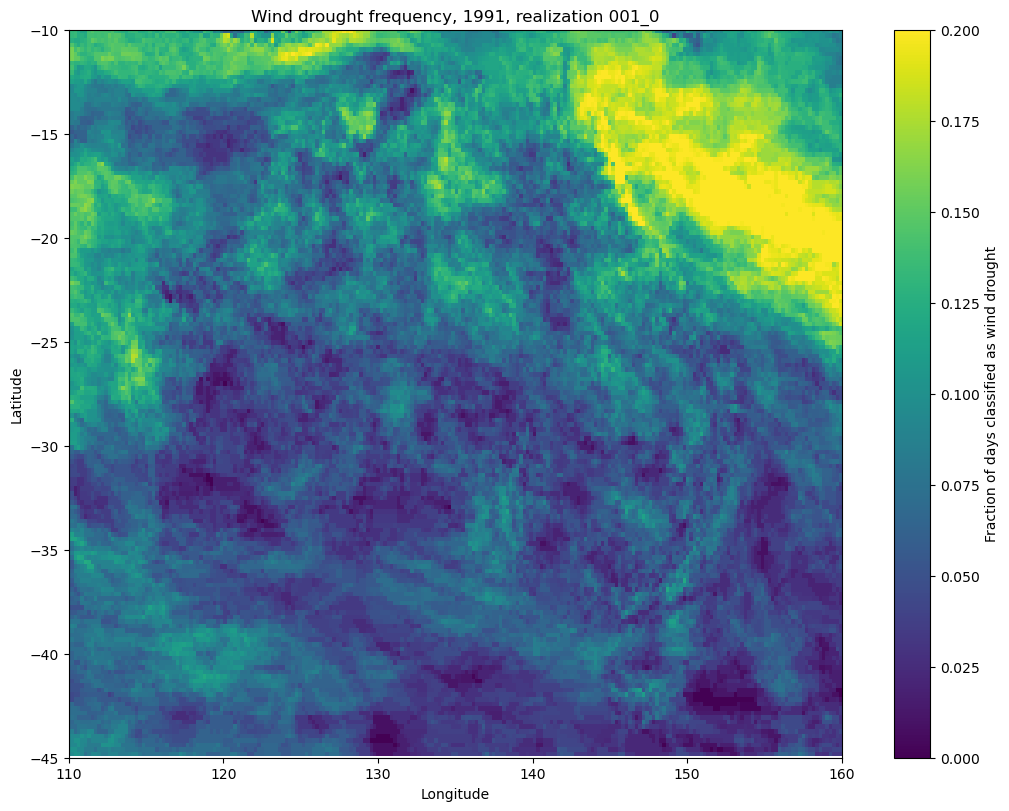

In [10]:
# =========================
# Optional: plot one year and one realization
# =========================

import matplotlib.pyplot as plt

PLOT_YEAR = years_to_process[1]
PLOT_REALIZATION_INDEX = 2

plot_file = OUT_DIR / f"wind_drought_P{THRESHOLD_PERCENTILE}_{PERSISTENCE_DAYS}day_{PLOT_YEAR}.nc"

ds_plot = xr.open_dataset(plot_file)

# Fraction of drought days in that year for one realization
freq = ds_plot["wind_drought"].isel(realization=PLOT_REALIZATION_INDEX).mean(dim="time")

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

da = freq.transpose("lat", "lon")

im = ax.pcolormesh(
    da["lon"],
    da["lat"],
    da,
    shading="auto",
    vmin=0,
    vmax=float(da.quantile(0.98).values),
)

ax.set_title(
    f"Wind drought frequency, {PLOT_YEAR}, realization {ds_plot['realization'].values[PLOT_REALIZATION_INDEX]}"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Fraction of days classified as wind drought")

plt.show()

ds_plot.close()

<xarray.Dataset> Size: 667kB
Dimensions:  (lat: 311, lon: 531)
Coordinates:
  * lat      (lat) float64 2kB -56.49 -56.27 -56.05 -55.83 ... 11.27 11.49 11.71
  * lon      (lon) float64 4kB 89.53 89.75 89.97 90.19 ... 205.7 205.9 206.1
    crs      int32 4B ...
Data variables:
    sftlf    (lat, lon) float32 661kB ...
Attributes: (12/55)
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    axiom_schema:              cordex-fx.json
    productive_version:        ea0e968
    variable_version:          v20240516
    Conventions:               CF-1.10, ACDD-1.3
    ...                        ...
    date_modified:             2024-10-11T00:56:48Z
    date_metadata_modified:    2024-10-11T00:56:48Z
    history:                   Tue Apr 30 07:38:05 2024: /g/data/access/ngm/m...
    references:                https://doi.org/10.25914/1x6g-2v48
    license:                   https://doi.org/10.25914/1x6g-2v48
    acknowledgement:           The production of BARRA2 was s

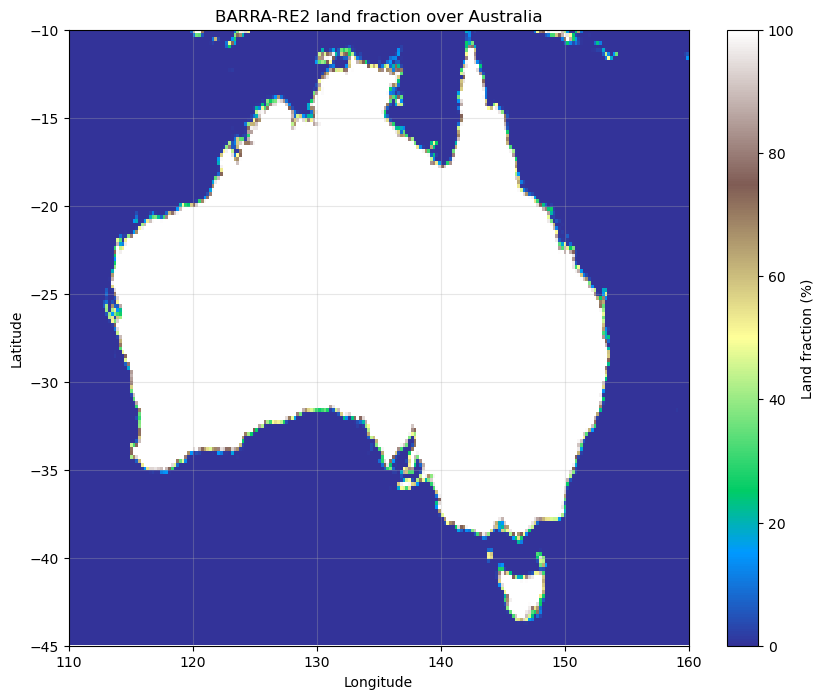

In [11]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

sftlf_path = "/g/data/ob53/BARRA2/output/reanalysis/AUS-22/BOM/ERA5/historical/eda/BARRA-RE2/v1/fx/sftlf/v20240516/sftlf_AUS-22_ERA5_historical_eda_BOM_BARRA-RE2_v1.nc"

ds_sftlf = xr.open_dataset(sftlf_path, engine="netcdf4", decode_times=True)

print(ds_sftlf)
print("Variables:", list(ds_sftlf.data_vars))
print("Coordinates:", list(ds_sftlf.coords))

# Australia bounds
lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

# Variable
sftlf = ds_sftlf["sftlf"].squeeze()

# Detect coordinate names
lon_name = "lon" if "lon" in ds_sftlf.coords else "longitude"
lat_name = "lat" if "lat" in ds_sftlf.coords else "latitude"

lon = ds_sftlf[lon_name]
lat = ds_sftlf[lat_name]

# Crop using 2D or 1D lon/lat safely
aus_mask = (
    (lon >= lon_min) & (lon <= lon_max) &
    (lat >= lat_min) & (lat <= lat_max)
)

sftlf_aus = sftlf.where(aus_mask, drop=True)

print(sftlf_aus)

plt.figure(figsize=(10, 8))

# Use 2D lon/lat if available
if lon.ndim == 2 and lat.ndim == 2:
    lon_aus = lon.where(aus_mask, drop=True)
    lat_aus = lat.where(aus_mask, drop=True)

    im = plt.pcolormesh(
        lon_aus,
        lat_aus,
        sftlf_aus,
        shading="auto",
        vmin=0,
        vmax=100,
        cmap="terrain"
    )

else:
    im = sftlf_aus.plot(
        x=lon_name,
        y=lat_name,
        vmin=0,
        vmax=100,
        cmap="terrain",
        add_colorbar=False
    )

plt.colorbar(im, label="Land fraction (%)")

plt.title("BARRA-RE2 land fraction over Australia")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.grid(alpha=0.3)

plt.show()

In [12]:
from pathlib import Path
import os
import gc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FFMpegWriter
from tqdm.auto import tqdm

DROUGHT_DIR = Path("/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/")
SFTLF_FILE = Path("/g/data/ob53/BARRA2/output/reanalysis/AUS-22/BOM/ERA5/historical/eda/BARRA-RE2/v1/fx/sftlf/v20240516/sftlf_AUS-22_ERA5_historical_eda_BOM_BARRA-RE2_v1.nc")

VIDEO_DIR = Path("/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/videos/")
VIDEO_DIR.mkdir(parents=True, exist_ok=True)

OUT_VIDEO = VIDEO_DIR / "BARRA_RE2_wind_drought_1990_2025_Australia.mp4"

lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

START_YEAR = 1990
END_YEAR = 2025

# Video settings
FPS = 24

# 1 means every day is plotted.
# Use 2, 3, 5, or 7 for a faster test version.
DAY_STEP = 1

# Transition frames between two days.
# 0 = no transition.
# 1 or 2 is reasonable for full 1990 to 2025.
TRANSITION_FRAMES = 1

# Plot mode:
# "ensemble_fraction" = mean across 22 realizations, best for video
# "single_realization" = binary 0/1 mask for one realization
PLOT_MODE = "ensemble_fraction"
REALIZATION_INDEX = 0

year_files = []

for year in range(START_YEAR, END_YEAR + 1):
    fp = DROUGHT_DIR / f"wind_drought_P20_3day_{year}.nc"
    if fp.exists():
        year_files.append(fp)
    else:
        print(f"Missing file for {year}: {fp}")

print(f"Files found: {len(year_files)}")
print("First:", year_files[0])
print("Last :", year_files[-1])

with xr.open_dataset(year_files[0], engine="netcdf4", decode_times=True) as ds0:
    print(ds0)
    drought_var = list(ds0.data_vars)[0]
    print("Using drought variable:", drought_var)

    sample = ds0[drought_var]
    print("Drought dims:", sample.dims)
    print("Drought shape:", sample.shape)

ds_sftlf = xr.open_dataset(SFTLF_FILE, engine="netcdf4", decode_times=True)

print(ds_sftlf)
print("Variables:", list(ds_sftlf.data_vars))

sftlf = ds_sftlf["sftlf"].squeeze()

# Detect coordinate names
lon_name_s = "lon" if "lon" in ds_sftlf.coords else "longitude"
lat_name_s = "lat" if "lat" in ds_sftlf.coords else "latitude"

lon_s = ds_sftlf[lon_name_s]
lat_s = ds_sftlf[lat_name_s]

sftlf_mask = (
    (lon_s >= lon_min) & (lon_s <= lon_max) &
    (lat_s >= lat_min) & (lat_s <= lat_max)
)

sftlf_aus = sftlf.where(sftlf_mask, drop=True).load()

print(sftlf_aus)

Files found: 36
First: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
Last : /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_2025.nc
<xarray.Dataset> Size: 1GB
Dimensions:       (time: 365, realization: 22, lon: 227, lat: 159)
Coordinates:
  * time          (time) datetime64[ns] 3kB 1990-01-01T12:00:00 ... 1990-12-3...
  * realization   (realization) <U5 440B '000_0' '000_1' ... 'ctl_0' 'ctl_1'
  * lon           (lon) float64 2kB 110.2 110.4 110.7 ... 159.5 159.7 159.9
  * lat           (lat) float64 1kB -44.83 -44.61 -44.39 ... -10.29 -10.07
Data variables:
    wind_drought  (time, realization, lon, lat) float32 1GB ...
Attributes:
    title:    BARRA-RE2 wind drought mask for 1990
    history:  Created from monthly wind100 files using fixed 1991-2020 P20 th...
    region:   Australia
    lon_min:  110
    lon_max:  160
    lat_min:  -45
    lat_max:  -10
Using drought variable: wind_drought
Drought dims: ('tim

In [14]:
# Convert land fraction to 0 to 1
land_frac = (sftlf_aus / 100.0).clip(0, 1)

# Get cropped lon/lat directly from the cropped sftlf object
# This avoids applying a 2D mask to 1D lon/lat arrays
lon_s_aus = sftlf_aus[lon_name_s]
lat_s_aus = sftlf_aus[lat_name_s]

# Make clean land-only transparent layer
# Sea will stay white because values <= 0 are masked out
land_alpha = land_frac.where(land_frac > 0.01)

print("land_frac shape:", land_frac.shape)
print("land_alpha shape:", land_alpha.shape)
print("lon_s_aus shape:", lon_s_aus.shape)
print("lat_s_aus shape:", lat_s_aus.shape)
print("lon dims:", lon_s_aus.dims)
print("lat dims:", lat_s_aus.dims)

land_frac shape: (159, 227)
land_alpha shape: (159, 227)
lon_s_aus shape: (227,)
lat_s_aus shape: (159,)
lon dims: ('lon',)
lat dims: ('lat',)


In [17]:
def load_year_for_video(year_file):
    """
    Load one yearly wind drought file, crop Australia,
    and return daily maps for video.

    Output:
        time, lat, lon
    """

    ds = xr.open_dataset(year_file, engine="netcdf4", decode_times=True)

    da = ds[drought_var]

    # Crop Australia
    da = da.where(
        (da["lon"] >= lon_min) & (da["lon"] <= lon_max) &
        (da["lat"] >= lat_min) & (da["lat"] <= lat_max),
        drop=True
    )

    if PLOT_MODE == "ensemble_fraction":
        # Fraction of 22 realizations showing drought
        da = da.mean(dim="realization", skipna=True)

    elif PLOT_MODE == "single_realization":
        # Binary mask for one realization only
        da = da.isel(realization=REALIZATION_INDEX)

    else:
        ds.close()
        raise ValueError("PLOT_MODE must be 'ensemble_fraction' or 'single_realization'")

    da = da.transpose("time", "lat", "lon")

    if DAY_STEP > 1:
        da = da.isel(time=slice(0, None, DAY_STEP))

    da = da.load()

    ds.close()
    gc.collect()

    return da

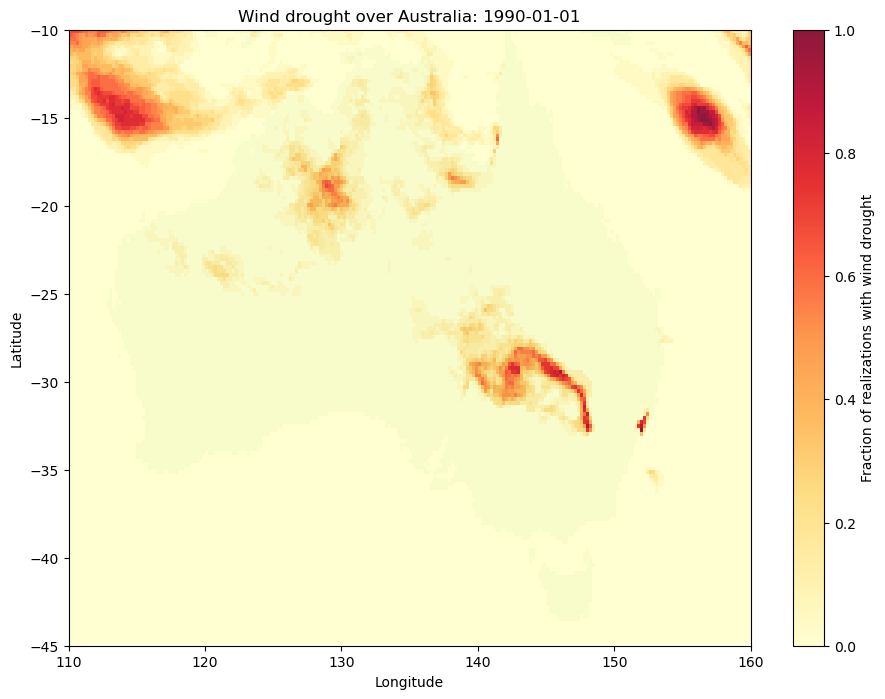

10604

In [18]:
test_da = load_year_for_video(year_files[0])
frame0 = test_da.isel(time=0)

fig, ax = plt.subplots(figsize=(11, 8))

ax.set_facecolor("white")

# Transparent green land background
land_cmap = mcolors.ListedColormap([(0.0, 0.45, 0.0, 0.25)])

ax.pcolormesh(
    lon_s_aus,
    lat_s_aus,
    land_alpha,
    shading="auto",
    cmap=land_cmap,
    vmin=0,
    vmax=1
)

# Wind drought overlay
im = ax.pcolormesh(
    frame0["lon"],
    frame0["lat"],
    frame0,
    shading="auto",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    alpha=0.90
)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Wind drought over Australia: {str(frame0.time.values)[:10]}")

cbar = plt.colorbar(im, ax=ax)

if PLOT_MODE == "ensemble_fraction":
    cbar.set_label("Fraction of realizations with wind drought")
else:
    cbar.set_label("Wind drought mask: 1 = drought, 0 = no drought")

plt.show()

del test_da, frame0
gc.collect()

In [19]:
fig, ax = plt.subplots(figsize=(11, 8))

writer = FFMpegWriter(
    fps=FPS,
    metadata={
        "title": "BARRA-RE2 wind drought over Australia",
        "artist": "Husnain Asif"
    },
    bitrate=3500
)

# Load first frame
da_first_year = load_year_for_video(year_files[0])
first_frame = da_first_year.isel(time=0)
first_values = first_frame.values.astype("float32")

ax.set_facecolor("white")

# Static transparent green land
land_cmap = mcolors.ListedColormap([(0.0, 0.45, 0.0, 0.25)])

ax.pcolormesh(
    lon_s_aus,
    lat_s_aus,
    land_alpha,
    shading="auto",
    cmap=land_cmap,
    vmin=0,
    vmax=1
)

# Dynamic drought layer
im = ax.pcolormesh(
    first_frame["lon"],
    first_frame["lat"],
    first_values,
    shading="auto",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    alpha=0.90
)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

title = ax.set_title("")

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)

if PLOT_MODE == "ensemble_fraction":
    cbar.set_label("Fraction of realizations with wind drought")
else:
    cbar.set_label("Wind drought mask: 1 = drought, 0 = no drought")

fig.tight_layout()

with writer.saving(fig, str(OUT_VIDEO), dpi=160):

    previous_frame = None
    previous_time = None

    for yf in tqdm(year_files, desc="Rendering years", unit="year"):

        da_year = load_year_for_video(yf)

        for t in tqdm(range(da_year.sizes["time"]), desc=f"Days {yf.stem[-4:]}", leave=False):

            current = da_year.isel(time=t)
            current_values = current.values.astype("float32")
            current_time = str(current.time.values)[:10]

            # Smooth transition from previous day to current day
            if previous_frame is not None and TRANSITION_FRAMES > 0:

                for k in range(1, TRANSITION_FRAMES + 1):
                    blend_weight = k / (TRANSITION_FRAMES + 1)

                    blended = (
                        previous_frame * (1.0 - blend_weight) +
                        current_values * blend_weight
                    )

                    im.set_array(blended.ravel())
                    title.set_text(
                        f"BARRA-RE2 wind drought over Australia\n"
                        f"{previous_time} to {current_time}"
                    )

                    writer.grab_frame()

            # Actual daily frame
            im.set_array(current_values.ravel())
            title.set_text(
                f"BARRA-RE2 wind drought over Australia\n"
                f"{current_time}"
            )

            writer.grab_frame()

            previous_frame = current_values
            previous_time = current_time

        del da_year
        gc.collect()

plt.close(fig)

del da_first_year, first_frame, first_values
gc.collect()

print(f"Saved video: {OUT_VIDEO}")

Rendering years:   0%|          | 0/36 [00:00<?, ?year/s]

Days 1990:   0%|          | 0/365 [00:00<?, ?it/s]

Days 1991:   0%|          | 0/365 [00:00<?, ?it/s]

Days 1992:   0%|          | 0/366 [00:00<?, ?it/s]

Days 1993:   0%|          | 0/365 [00:00<?, ?it/s]

...

Days 2022:   0%|          | 0/365 [00:00<?, ?it/s]

Days 2023:   0%|          | 0/365 [00:00<?, ?it/s]

Days 2024:   0%|          | 0/366 [00:00<?, ?it/s]

Days 2025:   0%|          | 0/120 [00:00<?, ?it/s]

Saved video: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/videos/BARRA_RE2_wind_drought_1990_2025_Australia.mp4
